In [144]:
# Clear all variables and import libraries
%reset -f
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
from scipy.interpolate import griddata
import re
import os
from math import ceil

In [145]:
# Configuration - Update these paths to your data folders
sim_folder = r'../Downloaded_data/30_Degree_Old_simulation_results/30_Degree_Old_simulation_results/CSV_files/Sim_csv_files/pos3_transformed'
exp_folder = r'../Downloaded_data/30_Degree_Old_simulation_results/30_Degree_Old_simulation_results/CSV_files/Exp_csv_files/pos3_transformed'  # Path to experimental data for comparison
output_dir = '../Velocity_analysis_simulation_only'

z_velocity_offset = 0.0  # Constant term to add to simulation Z-velocity [m/s]
# Define distance steps from bottom (in meters)
distance_step = 0.002  # 2 mm steps
max_distance = 0.009   # Up to 9 mm from bottom

In [146]:
# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load all CSV files
sim_files = glob.glob(f"{sim_folder}/*.csv")
exp_files = glob.glob(f"{exp_folder}/*.csv")

sim_files.sort()
sim_files = sim_files[::-1]  # Reverse to match layer order
exp_files.sort()
exp_files = exp_files[::-1]  # Reverse to match layer order

print(f"Found {len(sim_files)} simulation files")
print(f"Found {len(exp_files)} experimental files")

# Load dataframes
sim_dataframes = [pd.read_csv(file) for file in sim_files]
exp_dataframes = [pd.read_csv(file) for file in exp_files] if len(exp_files) > 0 else []

# Extract file names for layer labels
sim_file_names = [os.path.basename(file) for file in sim_files]
exp_file_names = [os.path.basename(file) for file in exp_files] if len(exp_files) > 0 else []

print(f"\nSimulation files: {sim_file_names}")
if len(exp_file_names) > 0:
    print(f"Experimental files: {exp_file_names}")

# Auto-detect position and Reynolds number from first filename
test_filename = sim_file_names[0]

# Extract position
pos_match = re.search(r'Pos(\d+)', test_filename)
if pos_match:
    position = int(pos_match.group(1))
    print(f"Automatically detected Position: {position}")
else:
    position = 1  # Default fallback
    print(f"Could not detect position from filename, using default: {position}")

# Extract Reynolds number
re_match = re.search(r'Re(\d+)', test_filename)
if re_match:
    Re_p = int(re_match.group(1))
    print(f"Automatically detected Re_p: {Re_p}")
else:
    Re_p = 100  # Default fallback
    print(f"Could not detect Re_p from filename, using default: {Re_p}")

# Flip layers L06 to L12 by 180 degrees
print("\n" + "="*80)
print("Flipping layers L06 to L12 by 180 degrees...")
print("="*80)

# Column names for simulation data (will be set properly in next cell, but defining here for flip)
sim_x_col_temp = 'Points_0'
sim_z_col_temp = 'Points_2'
sim_u_col_temp = 'av_u_0'
sim_w_col_temp = 'av_u_2'

for i, (df_sim, filename) in enumerate(zip(sim_dataframes, sim_file_names)):
    # Extract layer number
    layer_match = re.search(r'L(\d{2})', filename)
    if layer_match:
        layer_num = int(layer_match.group(1))
        
        # Check if layer is in range L06-L12
        if 6 <= layer_num <= 12:
            print(f"Flipping Layer L{layer_num:02d}: {filename}")
            
            # Get center points for rotation
            x_center = (df_sim[sim_x_col_temp].min() + df_sim[sim_x_col_temp].max()) / 2
            z_center = (df_sim[sim_z_col_temp].min() + df_sim[sim_z_col_temp].max()) / 2
            
            # Flip by 180 degrees: rotate around center point
            df_sim[sim_x_col_temp] = 2 * x_center - df_sim[sim_x_col_temp]
            #df_sim[sim_z_col_temp] = 2 * z_center - df_sim[sim_z_col_temp]
            
            # Reverse velocity directions
            df_sim[sim_u_col_temp] = -df_sim[sim_u_col_temp]
            df_sim[sim_w_col_temp] = -df_sim[sim_w_col_temp]

print("Flipping complete!")
print("="*80 + "\n")

Found 15 simulation files
Found 5 experimental files

Simulation files: ['SIM_L17_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L16_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L15_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L14_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L13_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L12_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L11_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L10_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L09_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L08_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L07_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L06_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L05_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L04_Pos3_Re100_B0001_T_transformed.csv', 'SIM_L03_Pos3_Re100_B0001_T_transformed.csv']
Experimental files: ['L17_Pos03_Re100_B0001_T_transformed.csv', 'L16_Pos03_Re100_B0001_T_transformed.csv', 'L15_Pos03_Re100_B0001_T_transformed.csv', 'L14_Pos03_Re100_B0001_T_transformed.csv', 'L13_Pos03_Re100_B0001_T_transformed.csv']
A

In [ ]:
# Plot parameters
n_grid = 500      # Grid resolution for contour
n_arrows = 14    # Number of arrows for streamplot

# Column name mappings
# Experimental data uses these column names
exp_x_col = 'x'
exp_z_col = 'z'
exp_u_col = 'Vel_u'
exp_w_col = 'Vel_w'

# Simulation data uses these column names
sim_x_col = 'Points_0'
sim_z_col = 'Points_2'
sim_u_col = 'av_u_0'
sim_w_col = 'av_u_2'

print(f"Grid resolution: {n_grid}")
print(f"Streamplot arrows: {n_arrows}")

# Apply z_velocity_offset to simulation data and calculate velocity magnitudes
print("Applying z_velocity_offset to simulation data...")
for df_sim in sim_dataframes:
    df_sim[sim_w_col] = df_sim[sim_w_col] + z_velocity_offset

print("Calculating velocity magnitudes...")

all_vel_mag_values = []

# Calculate for simulation data (with offset already applied)
for df_sim in sim_dataframes:
    df_sim['vel_magnitude'] = np.sqrt(df_sim[sim_u_col]**2 + df_sim[sim_w_col]**2)
    all_vel_mag_values.extend(df_sim['vel_magnitude'].values)

# Calculate for experimental data if available
if len(exp_dataframes) > 0:
    for df_exp in exp_dataframes:
        df_exp['vel_magnitude'] = np.sqrt(df_exp[exp_u_col]**2 + df_exp[exp_w_col]**2)
        all_vel_mag_values.extend(df_exp['vel_magnitude'].values)

# Calculate common colorbar limits from all data
all_vel_mag_values = np.array(all_vel_mag_values)
all_vel_mag_values = all_vel_mag_values[np.isfinite(all_vel_mag_values)]  # Remove NaN and inf

common_vmin = all_vel_mag_values.min()
common_vmax = all_vel_mag_values.max()

print(f"\nCalculated velocity magnitude range from all data:")
print(f"  Min: {common_vmin:.6f} m/s")
print(f"  Max: {common_vmax:.6f} m/s")

levels = np.linspace(common_vmin, common_vmax, 50)

# Determine z-range for line plots
z_min_sim = float(min(df[sim_z_col].min() for df in sim_dataframes))
z_max_sim = float(max(df[sim_z_col].max() for df in sim_dataframes))

Grid resolution: 50
Streamplot arrows: 14
Applying z_velocity_offset to simulation data...
Calculating velocity magnitudes...

Calculated velocity magnitude range from all data:
  Min: 0.000000 m/s
  Max: 0.846727 m/s


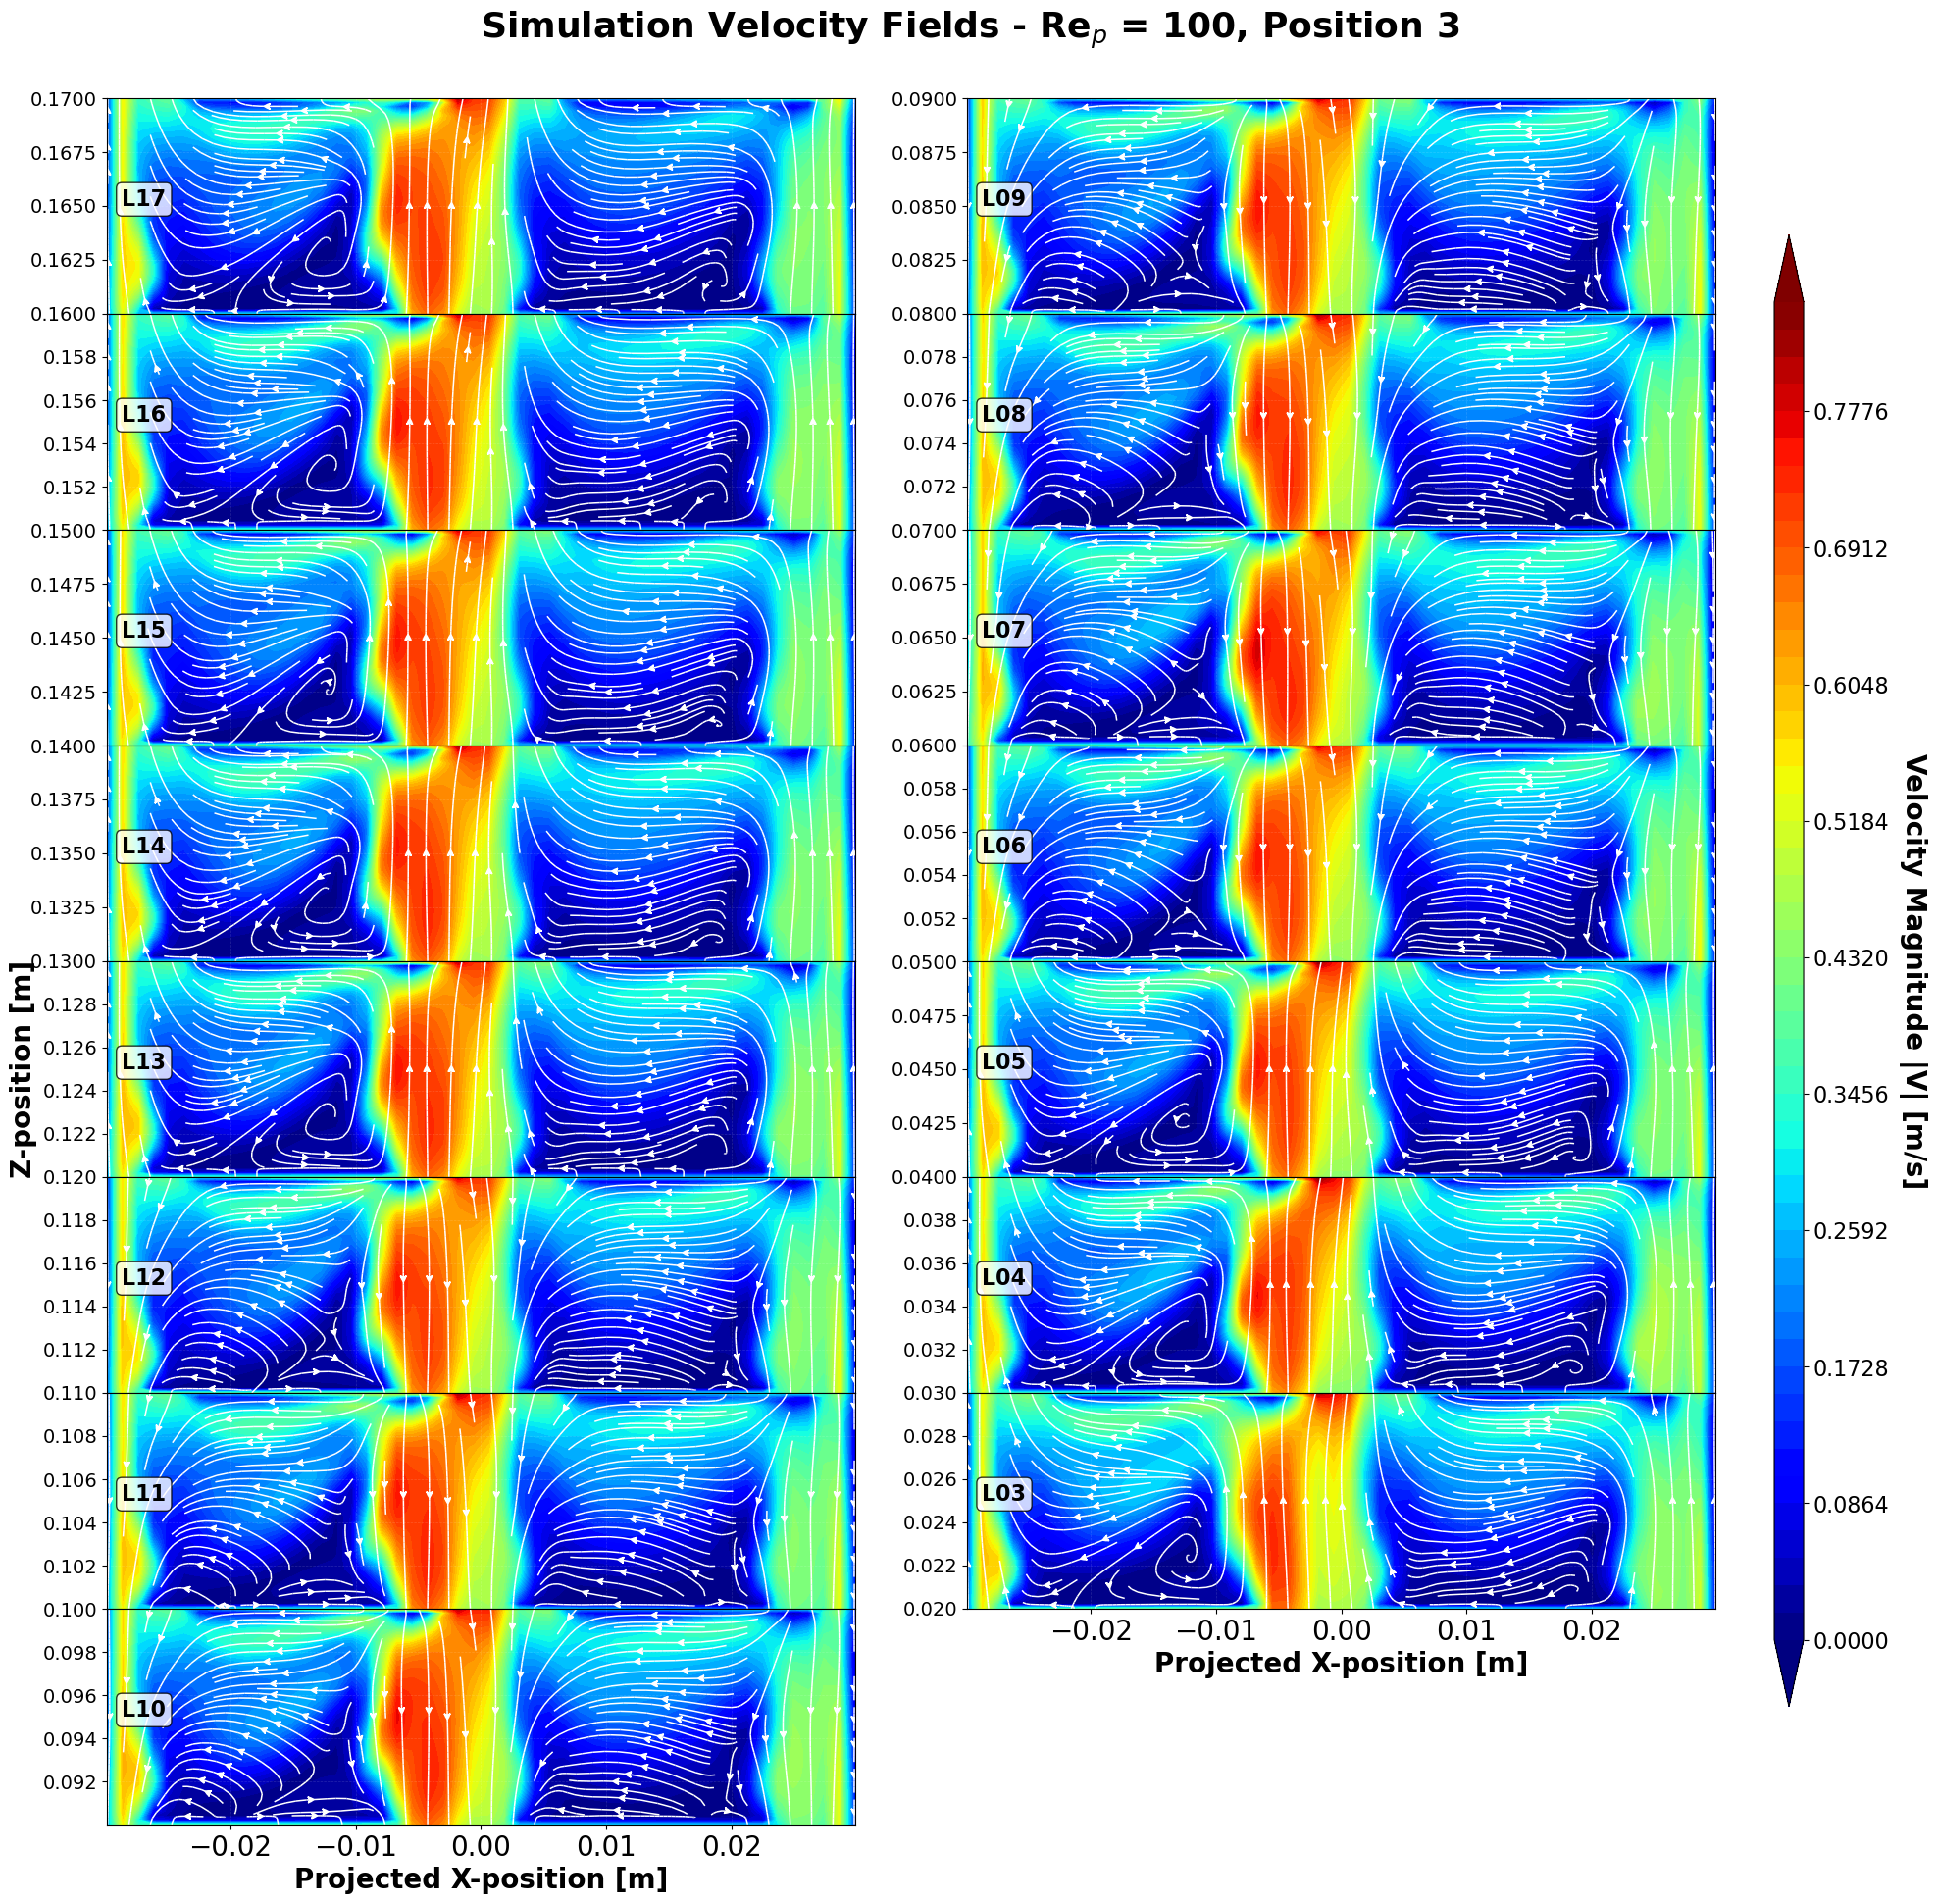

In [ ]:
# Simulation visualization plot (publication-ready layout)
# Split into 2 columns for better visualization
# ============================================================

n_layers = len(sim_dataframes)

# Split layers into two halves
n_half = int(np.ceil(n_layers / 2))  # First column gets extra layer if odd number
n_left = n_half
n_right = n_layers - n_half

fig, axes = plt.subplots(
    nrows=max(n_left, n_right),
    ncols=2,
    figsize=(20, 2.5 * max(n_left, n_right))
)

# Ensure axes is 2D
if max(n_left, n_right) == 1:
    axes = axes.reshape(1, -1)

# --- Global X-limits for alignment ---
x_min_global = min(df[sim_x_col].min() for df in sim_dataframes)
x_max_global = max(df[sim_x_col].max() for df in sim_dataframes)

# Process LEFT column (first half of layers)
for i in range(n_left):
    df_sim = sim_dataframes[i]

    # ----- Layer label -----
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"

    ax_sim = axes[i, 0]

    x_sim = df_sim[sim_x_col].values
    z_sim = df_sim[sim_z_col].values
    u_sim = df_sim[sim_u_col].values
    w_sim = df_sim[sim_w_col].values
    vel_mag_sim = df_sim['vel_magnitude'].values

    xi = np.linspace(x_sim.min(), x_sim.max(), n_grid)
    zi = np.linspace(z_sim.min(), z_sim.max(), n_grid)
    Xi, Zi = np.meshgrid(xi, zi)

    points = np.column_stack((x_sim, z_sim))
    Ui = griddata(points, u_sim, (Xi, Zi), method='linear', fill_value=0)
    Wi = griddata(points, w_sim - z_velocity_offset, (Xi, Zi), method='linear', fill_value=0)
    Vmag = griddata(points, vel_mag_sim, (Xi, Zi), method='linear', fill_value=0)

    mag = np.sqrt(Ui**2 + Wi**2)
    Ui_norm = np.zeros_like(Ui)
    Wi_norm = np.zeros_like(Wi)
    mask = mag > 1e-6
    Ui_norm[mask] = Ui[mask]/mag[mask]
    Wi_norm[mask] = Wi[mask]/mag[mask]

    contour_sim = ax_sim.contourf(
        Xi, Zi, Vmag,
        levels=levels, cmap='jet',
        vmin=common_vmin, vmax=common_vmax, extend='both'
    )
    ax_sim.streamplot(
        Xi, Zi, Ui_norm, Wi_norm,
        density=1.2, color='white',
        linewidth=1.1, arrowsize=1.0, arrowstyle='fancy'
    )

    # --- Set exact limits to remove extra space ---
    ax_sim.set_ylim(z_sim.min(), z_sim.max())
    ax_sim.set_xlim(x_min_global, x_max_global)
    ax_sim.margins(x=0, y=0)

    ax_sim.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax_sim.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_sim.tick_params(axis='y', left=True, labelleft=True, labelsize=14)

    # ----- Row label -----
    ax_sim.annotate(
        layer_label, xy=(0.02, 0.50), xycoords='axes fraction',
        fontsize=16, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8)
    )

# Process RIGHT column (second half of layers)
for i in range(n_right):
    layer_idx = n_left + i
    df_sim = sim_dataframes[layer_idx]

    # ----- Layer label -----
    sim_match = re.search(r'L(\d{2})', sim_file_names[layer_idx])
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {layer_idx+1}"

    ax_sim = axes[i, 1]

    x_sim = df_sim[sim_x_col].values
    z_sim = df_sim[sim_z_col].values
    u_sim = df_sim[sim_u_col].values
    w_sim = df_sim[sim_w_col].values
    vel_mag_sim = df_sim['vel_magnitude'].values

    xi = np.linspace(x_sim.min(), x_sim.max(), n_grid)
    zi = np.linspace(z_sim.min(), z_sim.max(), n_grid)
    Xi, Zi = np.meshgrid(xi, zi)

    points = np.column_stack((x_sim, z_sim))
    Ui = griddata(points, u_sim, (Xi, Zi), method='linear', fill_value=0)
    Wi = griddata(points, w_sim, (Xi, Zi), method='linear', fill_value=0)
    Vmag = griddata(points, vel_mag_sim, (Xi, Zi), method='linear', fill_value=0)

    mag = np.sqrt(Ui**2 + Wi**2)
    Ui_norm = np.zeros_like(Ui)
    Wi_norm = np.zeros_like(Wi)
    mask = mag > 1e-6
    Ui_norm[mask] = Ui[mask]/mag[mask]
    Wi_norm[mask] = Wi[mask]/mag[mask]

    contour_sim = ax_sim.contourf(
        Xi, Zi, Vmag,
        levels=levels, cmap='jet',
        vmin=common_vmin, vmax=common_vmax, extend='both'
    )
    ax_sim.streamplot(
        Xi, Zi, Ui_norm, Wi_norm,
        density=1.2, color='white',
        linewidth=1.1, arrowsize=1.0, arrowstyle='fancy'
    )

    # --- Set exact limits to remove extra space ---
    ax_sim.set_ylim(z_sim.min(), z_sim.max())
    ax_sim.set_xlim(x_min_global, x_max_global)
    ax_sim.margins(x=0, y=0)

    ax_sim.grid(True, linestyle='--', alpha=0.15, color='white', linewidth=0.5)
    ax_sim.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_sim.tick_params(axis='y', left=True, labelleft=True, labelsize=14)

    # ----- Row label -----
    ax_sim.annotate(
        layer_label, xy=(0.02, 0.50), xycoords='axes fraction',
        fontsize=16, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8)
    )

# Hide any unused subplots in right column
for i in range(n_right, max(n_left, n_right)):
    axes[i, 1].set_visible(False)

# ----- Bottom X labels -----
# Left column
axes[n_left-1, 0].tick_params(axis='x', bottom=True, labelbottom=True, labelsize=20)
axes[n_left-1, 0].set_xlabel('Projected X-position [m]', fontsize=20, fontweight='bold')

# Right column (if has data)
if n_right > 0:
    axes[n_right-1, 1].tick_params(axis='x', bottom=True, labelbottom=True, labelsize=20)
    axes[n_right-1, 1].set_xlabel('Projected X-position [m]', fontsize=20, fontweight='bold')

# ----- Y label on middle left plot -----
mid_left = n_left // 2
axes[mid_left, 0].set_ylabel('Z-position [m]', fontsize=20, fontweight='bold')
# ----- Layout: no vertical gaps -----
fig.subplots_adjust(
    right=0.88,
    left=0.06,
    top=0.94,     # ← pulls plots closer to title
    bottom=0.06,
    hspace=0.0,
    wspace=0.15
)

# ----- Colorbar -----
cbar_ax = fig.add_axes([0.91, 0.12, 0.015, 0.75])
cbar = fig.colorbar(contour_sim, cax=cbar_ax)
cbar.set_label(
    'Velocity Magnitude |V| [m/s]',
    rotation=270,
    labelpad=28,
    fontsize=20, fontweight='bold'
)
cbar.ax.tick_params(labelsize=16)

# ----- Title -----
fig.suptitle(
    f'Simulation Velocity Fields - Re$_p$ = {Re_p}, Position {position}',
    fontsize=26, fontweight='bold', y=0.985
)

#plt.savefig(f'{output_dir}/Simulation_Velocity_Fields_Pos{position}_Re{Re_p}.png', dpi=300, bbox_inches='tight')
plt.show()


Plotting at distances from bottom (mm): [2.0, 4.0, 6.0, 8.0]
Total number of plots: 4
Global X-axis range: [-0.030163, 0.030209] m


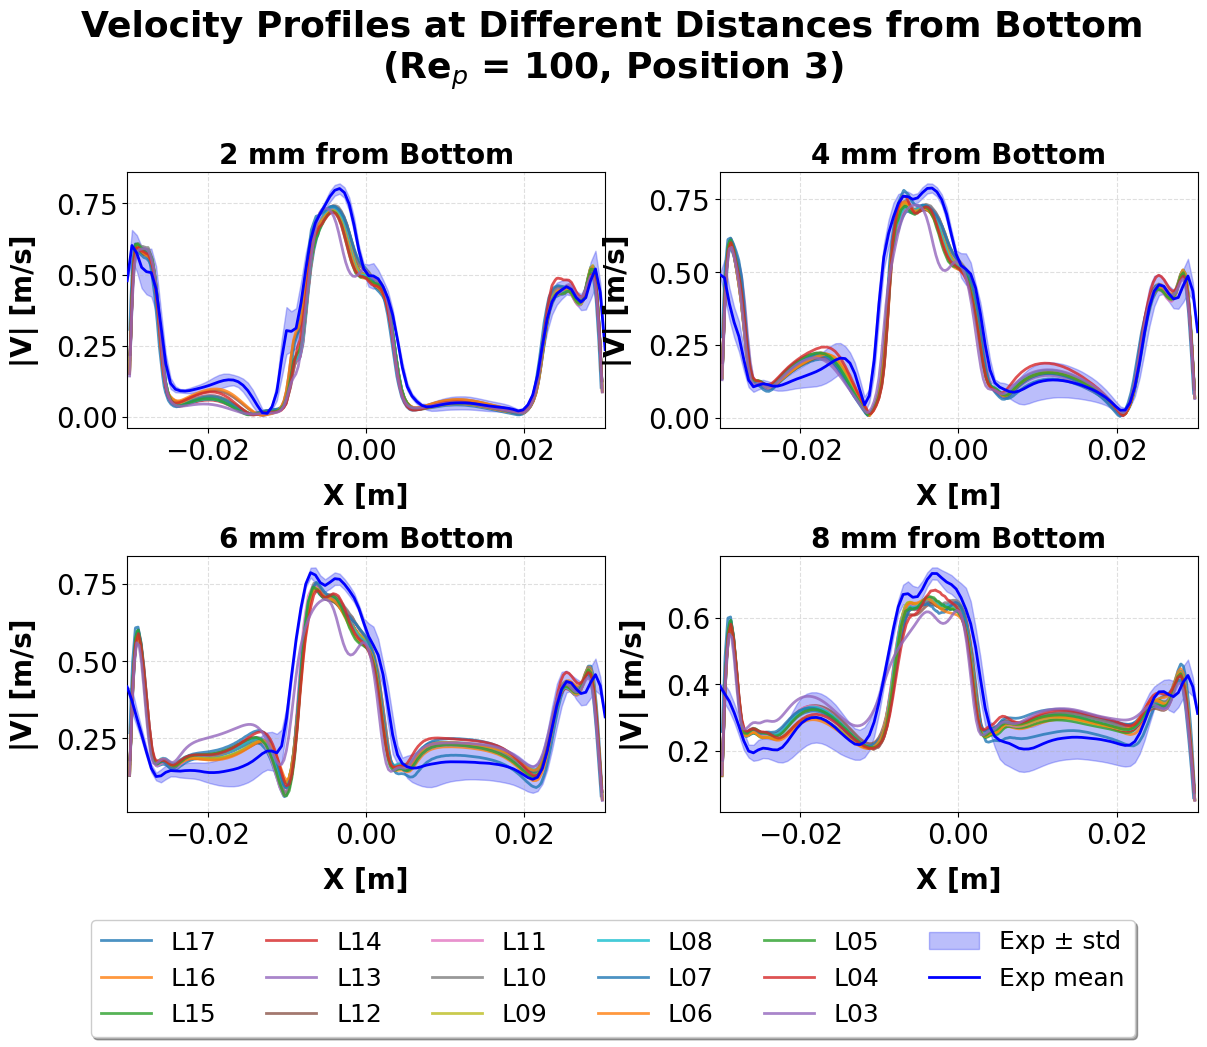

In [149]:
# Line plots at specific distances from bottom of layer
# Show all simulation layers + experimental mean with std deviation

distances_from_bottom = np.arange(distance_step, max_distance + 1e-12, distance_step)

print(f"\nPlotting at distances from bottom (mm): {[d*1000 for d in distances_from_bottom]}")
print(f"Total number of plots: {len(distances_from_bottom)}")

# Calculate global x-limits from all data for consistent x-axis across subplots
x_min_global_sim = min(df[sim_x_col].min() for df in sim_dataframes)
x_max_global_sim = max(df[sim_x_col].max() for df in sim_dataframes)

if len(exp_dataframes) > 0:
    x_min_global_exp = min(df[exp_x_col].min() for df in exp_dataframes)
    x_max_global_exp = max(df[exp_x_col].max() for df in exp_dataframes)
    x_min_global = min(x_min_global_sim, x_min_global_exp)
    x_max_global = max(x_max_global_sim, x_max_global_exp)
else:
    x_min_global = x_min_global_sim
    x_max_global = x_max_global_sim

print(f"Global X-axis range: [{x_min_global:.6f}, {x_max_global:.6f}] m")

# Determine subplot layout
n_plots = len(distances_from_bottom)
if n_plots <= 4:
    n_rows, n_cols = 2, 2
elif n_plots <= 6:
    n_rows, n_cols = 2, 3
elif n_plots <= 9:
    n_rows, n_cols = 3, 3
else:
    n_rows, n_cols = 3, 4

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

# Process each distance from bottom
for idx, distance in enumerate(distances_from_bottom):
    deci = 5  # Precision for filtering
    ax = axes[idx]
    
    # Plot all SIMULATION layers
    for i, df_sim in enumerate(sim_dataframes):
        # Calculate z-position for this layer (distance from its bottom)
        z_min_layer = df_sim[sim_z_col].min()
        z_target = z_min_layer + distance
        
        # Check if this distance exists in this layer
        if z_target <= df_sim[sim_z_col].max():
            # Find closest z-value in simulation data
            closest_z_sim = df_sim[sim_z_col].iloc[(df_sim[sim_z_col] - z_target).abs().argsort()[:1]].iloc[0]
            
            # Filter data at this Z-height
            df_sim_filtered = df_sim[abs(df_sim[sim_z_col] - closest_z_sim) < 10**(-deci)]
            
            if len(df_sim_filtered) > 0:
                df_sim_filtered = df_sim_filtered.sort_values(sim_x_col)
                
                # Extract layer label from filename
                sim_match = re.search(r'L(\d{2})', sim_file_names[i])
                layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
                
                # Plot simulation layer
                ax.plot(df_sim_filtered[sim_x_col], df_sim_filtered['vel_magnitude'], 
                       label=layer_label, linestyle='-', linewidth=2.0, alpha=0.8)
    
    # Calculate EXPERIMENTAL data statistics across all layers (if available)
    if len(exp_dataframes) > 0:
        # Collect data from all experimental layers at this distance from bottom
        all_exp_data = []
        
        for i, df_exp in enumerate(exp_dataframes):
            # Calculate z-position for this layer (distance from its bottom)
            z_min_layer = df_exp[exp_z_col].min()
            z_target = z_min_layer + distance
            
            # Check if this distance exists in this layer
            if z_target <= df_exp[exp_z_col].max():
                # Find closest z-value in experimental data
                closest_z_exp = df_exp[exp_z_col].iloc[(df_exp[exp_z_col] - z_target).abs().argsort()[:1]].iloc[0]
                
                # Filter data at this Z-height
                df_exp_filtered = df_exp[abs(df_exp[exp_z_col] - closest_z_exp) < 10**(-deci)]
                
                if len(df_exp_filtered) > 0:
                    df_exp_filtered = df_exp_filtered.sort_values(exp_x_col)
                    all_exp_data.append(df_exp_filtered)
        
        # Calculate mean and std across all experimental layers
        if len(all_exp_data) > 0:
            # Use global x-range for consistency
            x_grid = np.linspace(x_min_global, x_max_global, 100)
            
            vel_matrix = []
            
            for df_exp_layer in all_exp_data:
                x_layer = df_exp_layer[exp_x_col].values
                vel_layer = df_exp_layer['vel_magnitude'].values
                
                # Interpolate to common grid
                from scipy.interpolate import interp1d
                if len(x_layer) > 1:
                    f_interp = interp1d(x_layer, vel_layer, kind='linear', 
                                       bounds_error=False, fill_value=np.nan)
                    vel_interp = f_interp(x_grid)
                    vel_matrix.append(vel_interp)
            
            # Calculate mean and std across layers
            if len(vel_matrix) > 0:
                vel_matrix = np.array(vel_matrix)
                vel_mean = np.nanmean(vel_matrix, axis=0)
                vel_std = np.nanstd(vel_matrix, axis=0)
                
                # Plot experimental mean with std deviation
                ax.fill_between(x_grid, vel_mean - vel_std, vel_mean + vel_std,
                                color='#1e28f2', alpha=0.3, label='Exp ± std', zorder=1)
                ax.plot(x_grid, vel_mean, 'b-', label='Exp mean', 
                       linewidth=2.0, zorder=3)
    
    # Configure subplot with consistent x-limits
    ax.set_xlim(x_min_global, x_max_global)
    ax.set_xlabel('X [m]', fontsize=20, fontweight='bold', labelpad=12)  # moved lower
    ax.set_ylabel('|V| [m/s]', fontsize=20, fontweight='bold', labelpad=12)
    ax.set_title(f'{distance*1000:.0f} mm from Bottom', fontsize=20, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8)
    ax.tick_params(axis='both', labelsize=20)

# Hide unused subplots
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

# Create single legend at the bottom for all subplots
# Get handles and labels from the first subplot (they're all the same)
handles, labels = axes[0].get_legend_handles_labels()

# Place legend below all subplots in a single row
ncol = ceil(len(labels) / 3)  # Adjust number of columns based on number of labels
fig.legend(handles, labels, 
           loc='lower center', 
          # bbox_to_anchor=(0.5, -0.02),
           bbox_to_anchor=(0.5, -0.06),
           ncol=ncol,
           fontsize=18,
           frameon=True,
           fancybox=True,
           shadow=True)

# Add overall title
fig.suptitle(f'Velocity Profiles at Different Distances from Bottom\n(Re$_p$ = {Re_p}, Position {position})', 
            fontsize=26, fontweight='bold', y=0.98)

# Adjust layout
#plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.tight_layout(rect=[0, 0.08, 1, 0.96])   # ← increases bottom padding

# Save plot
#plot_filename = f'{output_dir}/Sim_Line_Profiles_from_Bottom_Pos{position}_Re{Re_p}.png'
#plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
#print(f"\nSaved: {plot_filename}")
plt.show()

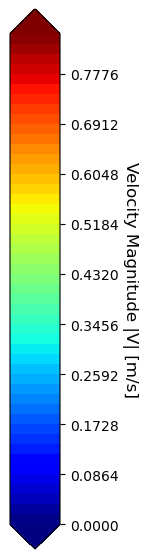

In [150]:
# Plot only vertical colorbar (uses existing `contour_sim`, `common_vmin`, `common_vmax`, `output_dir`, `position`, `Re_p`)
fig = plt.figure(figsize=(2, 6))
cax = fig.add_axes([0.18, 0.05, 0.25, 0.9])  # position for vertical colorbar
cbar = fig.colorbar(contour_sim, cax=cax, orientation='vertical')
cbar.set_label('Velocity Magnitude |V| [m/s]', rotation=270, labelpad=14, fontsize=12)
cbar.ax.tick_params(labelsize=10)
plt.savefig(f'{output_dir}/Colorbar_vertical_Pos{position}_Re{Re_p}.png', dpi=300, bbox_inches='tight')
plt.show()


SUMMARY: Maximum Velocity Magnitude Per Layer

Layer  Max_|V|_[m/s]  Max_u_[m/s]  Max_w_[m/s]
  L17       0.817416     0.412179     0.752667
  L16       0.798910     0.417137     0.757640
  L15       0.794923     0.394449     0.751638
  L14       0.821606     0.409950     0.761072
  L13       0.802209     0.417586     0.759595
  L12       0.798404     0.395619     0.066738
  L11       0.827309     0.409975     0.064512
  L10       0.808656     0.419598     0.061937
  L09       0.804163     0.397081     0.066726
  L08       0.828638     0.408960     0.062517
  L07       0.787682     0.427006     0.074919
  L06       0.795908     0.391211     0.069627
  L05       0.844499     0.406276     0.785690
  L04       0.846727     0.391038     0.804308
  L03       0.828934     0.342170     0.781003

Average Maximum Velocity [m/s]: 0.813732
Standard Deviation [m/s]: 0.018523
Overall Maximum Velocity [m/s]: 0.846727

Summary saved to: ../Velocity_analysis_simulation_only/Sim_Layer_Velocity_Summary

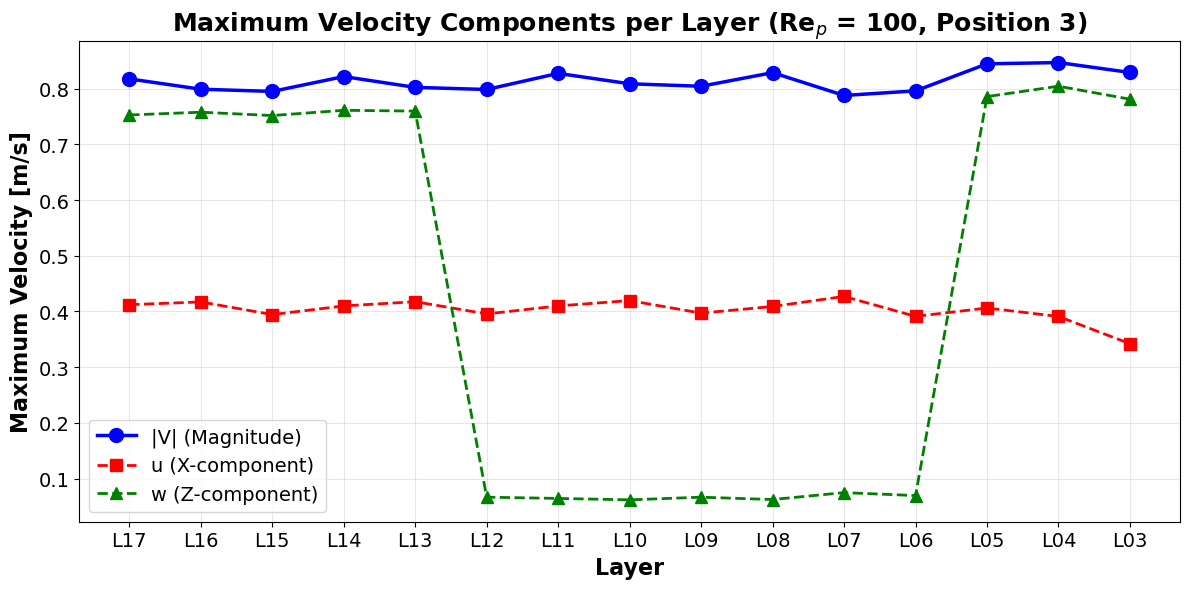

In [151]:
# Create summary DataFrame showing max velocities per layer
print("\n" + "="*80)
print("SUMMARY: Maximum Velocity Magnitude Per Layer")
print("="*80)

layer_names = []
layer_max_vel_sim = []
layer_max_u_sim = []
layer_max_w_sim = []

n_layers = len(sim_dataframes)

for i in range(n_layers):
    df_sim = sim_dataframes[i]
    
    # Extract layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_name = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    
    layer_names.append(layer_name)
    layer_max_vel_sim.append(df_sim['vel_magnitude'].max())
    layer_max_u_sim.append(df_sim[sim_u_col].max())
    layer_max_w_sim.append(df_sim[sim_w_col].max())

# Create summary DataFrame
summary_df = pd.DataFrame({
    'Layer': layer_names,
    'Max_|V|_[m/s]': layer_max_vel_sim,
    'Max_u_[m/s]': layer_max_u_sim,
    'Max_w_[m/s]': layer_max_w_sim
})

# Format and display
pd.options.display.float_format = '{:.6f}'.format
print("\n" + summary_df.to_string(index=False))

# Calculate statistics
avg_max_vel = summary_df['Max_|V|_[m/s]'].mean()
std_max_vel = summary_df['Max_|V|_[m/s]'].std()
overall_max = summary_df['Max_|V|_[m/s]'].max()

print(f"\nAverage Maximum Velocity [m/s]: {avg_max_vel:.6f}")
print(f"Standard Deviation [m/s]: {std_max_vel:.6f}")
print(f"Overall Maximum Velocity [m/s]: {overall_max:.6f}")
print("="*80 + "\n")

# Reset display format
pd.reset_option('display.float_format')

# Create plot showing max velocity per layer
fig, ax = plt.subplots(figsize=(12, 6))
x_positions = np.arange(len(layer_names))

ax.plot(x_positions, layer_max_vel_sim, 'bo-', label='|V| (Magnitude)', linewidth=2.5, markersize=10)
ax.plot(x_positions, layer_max_u_sim, 'rs--', label='u (X-component)', linewidth=2, markersize=8)
ax.plot(x_positions, layer_max_w_sim, 'g^--', label='w (Z-component)', linewidth=2, markersize=8)

ax.set_xlabel('Layer', fontsize=16, fontweight='bold')
ax.set_ylabel('Maximum Velocity [m/s]', fontsize=16, fontweight='bold')
ax.set_title(f'Maximum Velocity Components per Layer (Re$_p$ = {Re_p}, Position {position})', 
             fontsize=18, fontweight='bold')
ax.set_xticks(x_positions)
ax.set_xticklabels(layer_names)
ax.legend(fontsize=14, loc='best')
ax.grid(True, alpha=0.3)
ax.tick_params(labelsize=14)
plt.tight_layout()

# Save summary
summary_filename = f'{output_dir}/Sim_Layer_Velocity_Summary_Pos{position}_Re{Re_p}.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"Summary saved to: {summary_filename}")

# Save plot
plot_filename = f'{output_dir}/Sim_Max_Velocity_per_Layer_Pos{position}_Re{Re_p}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"Plot saved to: {plot_filename}")

plt.show()

In [152]:
# Final summary statistics
print("\n" + "="*80)
print("OVERALL SIMULATION STATISTICS")
print("="*80)

# Collect all velocity data
all_sim_u = []
all_sim_w = []
all_sim_mag = []

for df_sim in sim_dataframes:
    all_sim_u.extend(df_sim[sim_u_col].values)
    all_sim_w.extend(df_sim[sim_w_col].values)
    all_sim_mag.extend(df_sim['vel_magnitude'].values)

# Convert to arrays
all_sim_u = np.array(all_sim_u)
all_sim_w = np.array(all_sim_w)
all_sim_mag = np.array(all_sim_mag)

# Calculate statistics
stats_df = pd.DataFrame({
    'Component': ['u (X-velocity)', 'w (Z-velocity)', '|V| (Magnitude)'],
    'Min [m/s]': [all_sim_u.min(), all_sim_w.min(), all_sim_mag.min()],
    'Mean [m/s]': [all_sim_u.mean(), all_sim_w.mean(), all_sim_mag.mean()],
    'Max [m/s]': [all_sim_u.max(), all_sim_w.max(), all_sim_mag.max()],
    'Std Dev [m/s]': [all_sim_u.std(), all_sim_w.std(), all_sim_mag.std()]
})

pd.options.display.float_format = '{:.6f}'.format
print("\n" + stats_df.to_string(index=False))
print("\n" + "="*80)

# Save statistics
stats_filename = f'{output_dir}/Sim_Overall_Statistics_Pos{position}_Re{Re_p}.csv'
stats_df.to_csv(stats_filename, index=False)
print(f"\nStatistics saved to: {stats_filename}")

pd.reset_option('display.float_format')

print("\nAll outputs saved to:", output_dir)
print("\nAnalysis complete!")


OVERALL SIMULATION STATISTICS

      Component  Min [m/s]  Mean [m/s]  Max [m/s]  Std Dev [m/s]
 u (X-velocity)  -0.471801   -0.084514   0.427006       0.117563
 w (Z-velocity)  -0.785744    0.017464   0.804308       0.312541
|V| (Magnitude)   0.000013    0.280013   0.846727       0.201354


Statistics saved to: ../Velocity_analysis_simulation_only/Sim_Overall_Statistics_Pos3_Re100.csv

All outputs saved to: ../Velocity_analysis_simulation_only

Analysis complete!



MAXIMUM VELOCITY VS HEIGHT FROM BOTTOM
L17: Height = 160.00 mm, Max Vel = 0.817416 m/s
L16: Height = 150.00 mm, Max Vel = 0.798910 m/s
L15: Height = 140.00 mm, Max Vel = 0.794923 m/s
L14: Height = 130.00 mm, Max Vel = 0.821606 m/s
L13: Height = 120.00 mm, Max Vel = 0.802209 m/s
L12: Height = 110.00 mm, Max Vel = 0.798404 m/s
L11: Height = 100.00 mm, Max Vel = 0.827309 m/s
L10: Height = 90.00 mm, Max Vel = 0.808656 m/s
L09: Height = 80.00 mm, Max Vel = 0.804163 m/s
L08: Height = 70.00 mm, Max Vel = 0.828638 m/s
L07: Height = 60.00 mm, Max Vel = 0.787682 m/s
L06: Height = 50.00 mm, Max Vel = 0.795908 m/s
L05: Height = 40.00 mm, Max Vel = 0.844499 m/s
L04: Height = 30.00 mm, Max Vel = 0.846727 m/s
L03: Height = 20.00 mm, Max Vel = 0.828934 m/s

Experimental L15: Height = 140.47 mm, Max Vel = 0.816061 m/s

Plot saved to: ../Velocity_analysis_simulation_only/Max_Velocity_vs_Height_Pos3_Re100.png


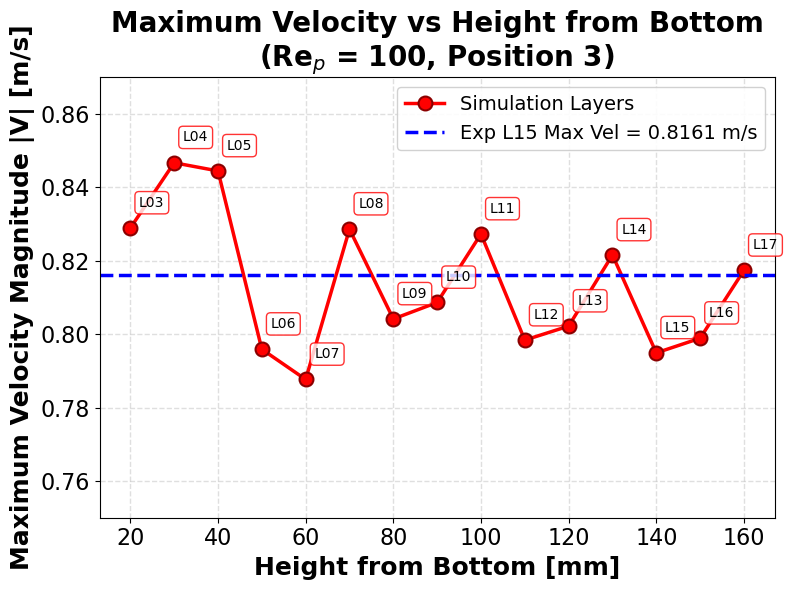

In [153]:
# Maximum velocity vs height from bottom
# Compare simulation layers with experimental layer 15
print("\n" + "="*80)
print("MAXIMUM VELOCITY VS HEIGHT FROM BOTTOM")
print("="*80)

# Calculate height from bottom for each simulation layer
sim_heights_m = []
sim_max_vels = []
sim_layer_labels = []

for i, df_sim in enumerate(sim_dataframes):
    # Get the bottom z-position of this layer
    z_bottom = df_sim[sim_z_col].min()
    z_top = df_sim[sim_z_col].max()
    
    # Use the bottom of the layer as height
    height_bottom = z_bottom
    
    sim_heights_m.append(height_bottom)
    sim_max_vels.append(df_sim['vel_magnitude'].max())
    
    # Extract layer label
    sim_match = re.search(r'L(\d{2})', sim_file_names[i])
    layer_label = f"L{sim_match.group(1)}" if sim_match else f"Layer {i+1}"
    sim_layer_labels.append(layer_label)
    print(f"{layer_label}: Height = {height_bottom*1000:.2f} mm, Max Vel = {sim_max_vels[-1]:.6f} m/s")

# Convert heights to mm
sim_heights_mm = np.array(sim_heights_m) * 1000

# Find experimental layer 15 if available
exp_layer15_height_mm = None
exp_layer15_max_vel = None

if len(exp_dataframes) > 0:
    for i, (df_exp, filename) in enumerate(zip(exp_dataframes, exp_file_names)):
        # Extract layer number from experimental filename
        exp_match = re.search(r'L(\d{2})', filename)
        if exp_match:
            layer_num = int(exp_match.group(1))
            if layer_num == 15:
                z_bottom = df_exp[exp_z_col].min()
                exp_layer15_height_mm = z_bottom * 1000
                exp_layer15_max_vel = df_exp['vel_magnitude'].max()
                print(f"\nExperimental L15: Height = {exp_layer15_height_mm:.2f} mm, Max Vel = {exp_layer15_max_vel:.6f} m/s")
                break
    
    if exp_layer15_max_vel is None:
        print("\nWarning: Experimental Layer 15 not found in data")

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot simulation data
ax.plot(sim_heights_mm, sim_max_vels, 'ro-', label='Simulation Layers', 
        linewidth=2.5, markersize=10, markeredgecolor='darkred', markeredgewidth=1.5)

# Add layer labels near each point
for i, (height, vel, label) in enumerate(zip(sim_heights_mm, sim_max_vels, sim_layer_labels)):
    # Offset the text slightly to avoid overlapping with the marker
    offset_x = 2  # mm offset
    offset_y = 0.005  # m/s offset
    
    ax.annotate(
        label, 
        xy=(height, vel), 
        xytext=(height + offset_x, vel + offset_y),
        fontsize=10, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='red', alpha=0.8),
        ha='left',
        va='bottom'
    )

# Plot experimental layer 15 if available
if exp_layer15_max_vel is not None:
    # Plot horizontal line at experimental L15 max velocity
    ax.axhline(exp_layer15_max_vel, color='blue', linestyle='--', linewidth=2.5, 
               label=f'Exp L15 Max Vel = {exp_layer15_max_vel:.4f} m/s', zorder=2)

# Configure axes
ax.set_xlabel('Height from Bottom [mm]', fontsize=18, fontweight='bold')
ax.set_ylabel('Maximum Velocity Magnitude |V| [m/s]', fontsize=18, fontweight='bold')
ax.set_title(f'Maximum Velocity vs Height from Bottom\n(Re$_p$ = {Re_p}, Position {position})', 
             fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.4, linestyle='--', linewidth=1)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=14, loc='best', framealpha=0.9)
ax.set_ylim(0.75,0.87)

# Add zero reference line
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)

plt.tight_layout()

# Save plot
plot_filename = f'{output_dir}/Max_Velocity_vs_Height_Pos{position}_Re{Re_p}.png'
plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
print(f"\nPlot saved to: {plot_filename}")

plt.show()

print("="*80)